In [41]:
# Import Libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor


In [42]:
# Load Dataset
cars_data = pd.read_csv('Cardetails.csv')

cars_data.head()


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [43]:
# Drop unnecessary column
cars_data.drop(columns=['torque'], inplace=True)


In [44]:
# Remove NULL values
cars_data.isnull().sum()


name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          221
engine           221
max_power        215
seats            221
dtype: int64

In [45]:
cars_data.dropna(inplace=True)


In [46]:
# Remove duplicates
cars_data.duplicated().sum()


np.int64(1189)

In [47]:
cars_data.drop_duplicates(inplace=True)


In [48]:
cars_data.info()


<class 'pandas.core.frame.DataFrame'>
Index: 6718 entries, 0 to 8125
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           6718 non-null   object 
 1   year           6718 non-null   int64  
 2   selling_price  6718 non-null   int64  
 3   km_driven      6718 non-null   int64  
 4   fuel           6718 non-null   object 
 5   seller_type    6718 non-null   object 
 6   transmission   6718 non-null   object 
 7   owner          6718 non-null   object 
 8   mileage        6718 non-null   object 
 9   engine         6718 non-null   object 
 10  max_power      6718 non-null   object 
 11  seats          6718 non-null   float64
dtypes: float64(1), int64(3), object(8)
memory usage: 682.3+ KB


In [49]:
# Extract brand name from car name
def get_brand_name(car_name):
    return car_name.split(' ')[0]

cars_data['name'] = cars_data['name'].apply(get_brand_name)


In [50]:
# Clean numeric columns
def clean_data(value):
    value = str(value).split(' ')[0].strip()
    
    if value == '' or value == 'nan':
        return np.nan
    
    return float(value)

cars_data['mileage'] = cars_data['mileage'].apply(clean_data)
cars_data['engine'] = cars_data['engine'].apply(clean_data)
cars_data['max_power'] = cars_data['max_power'].apply(clean_data)


In [51]:
cars_data.head()


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,Maruti,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,5.0
1,Skoda,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,Honda,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78.00,5.0
3,Hyundai,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.00,5.0
4,Maruti,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.20,5.0


In [52]:
# Remove outliers using IQR
Q1 = cars_data['selling_price'].quantile(0.25)
Q3 = cars_data['selling_price'].quantile(0.75)
IQR = Q3 - Q1

cars_data = cars_data[
    (cars_data['selling_price'] >= Q1 - 1.5 * IQR) &
    (cars_data['selling_price'] <= Q3 + 1.5 * IQR)
]


In [53]:
# Encode categorical variables using One-Hot Encoding
cars_data = pd.get_dummies(
    cars_data,
    columns=['name','fuel','seller_type','transmission','owner'],
    drop_first=True
)


In [54]:
cars_data.head()


,year,selling_price,km_driven,mileage,engine,max_power,seats,name_Ashok,name_Audi,name_BMW,...,name_Volvo,fuel_Diesel,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual,owner_Fourth & Above Owner,owner_Second Owner,owner_Third Owner
0,2014,450000,145500,23.40,1248.0,74.00,5.0,False,False,False,...,False,True,False,False,True,False,True,False,False,False
1,2014,370000,120000,21.14,1498.0,103.52,5.0,False,False,False,...,False,True,False,False,True,False,True,False,True,False
2,2006,158000,140000,17.70,1497.0,78.00,5.0,False,False,False,...,False,False,False,True,True,False,True,False,False,True
3,2010,225000,127000,23.00,1396.0,90.00,5.0,False,False,False,...,False,True,False,False,True,False,True,False,False,False
4,2007,130000,120000,16.10,1298.0,88.20,5.0,False,False,False,...,False,False,False,True,True,False,True,False,False,False


In [55]:
# Split features and target
X = cars_data.drop(columns=['selling_price'])
y = cars_data['selling_price']


In [56]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [57]:
# Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [58]:
# Train Model (Random Forest)
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [59]:
# Prediction
predictions = model.predict(X_test)

predictions[:10]


array([678674.995     , 230449.98      , 378815.66333333, 197227.04333333,
       472537.4725    , 249979.13666667, 653965.        , 272799.99      ,
       370186.21119048, 975349.975     ])

In [60]:
# Model Evaluation
r2 = r2_score(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("Model Accuracy (R2 Score):", round(r2*100,2), "%")
print("Mean Absolute Error:", round(mae,2))
print("RMSE:", round(rmse,2))


Model Accuracy (R2 Score): 89.51 %
Mean Absolute Error: 59376.21
RMSE: 83842.63


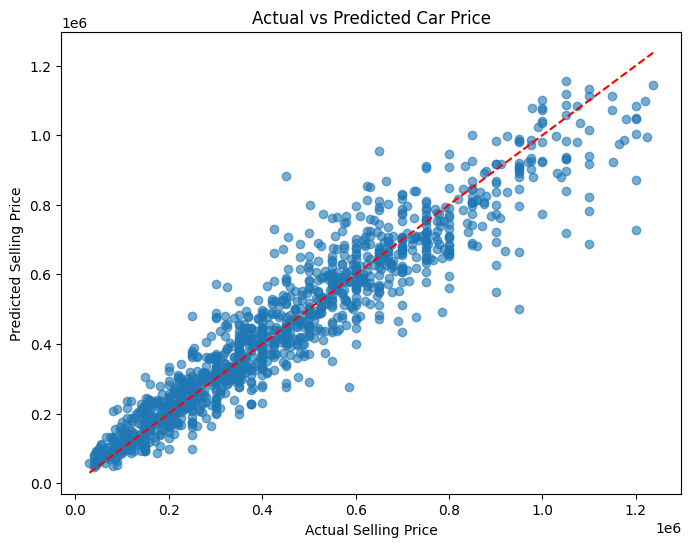

In [61]:
# Scatter Plot (Actual vs Predicted)
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, predictions, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Car Price")
plt.show()


In [62]:
model_columns = X.columns

import pickle

pickle.dump(model, open('car_price_model.pkl','wb'))
pickle.dump(model_columns, open('model_columns.pkl','wb'))